In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Wholesale customers data.csv")

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
X = df[
    [
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents_Paper",
        "Delicassen"
    ]
]

X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [9]:
inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

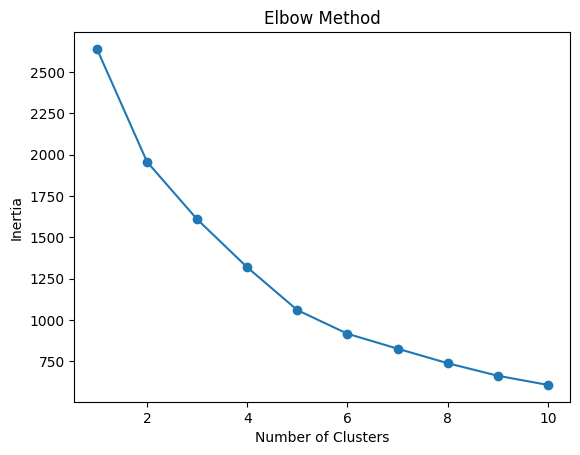

In [10]:
plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [11]:
k = 3

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
1    393
0     45
2      2
Name: count, dtype: int64


In [13]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    261
-1    174
 1      5
Name: count, dtype: int64


In [14]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[ 0.19329055, -0.30509996],
       [ 0.4344199 , -0.32841262],
       [ 0.81114323,  0.8150957 ],
       [-0.77864783,  0.65275373],
       [ 0.16628726,  1.27143372]])

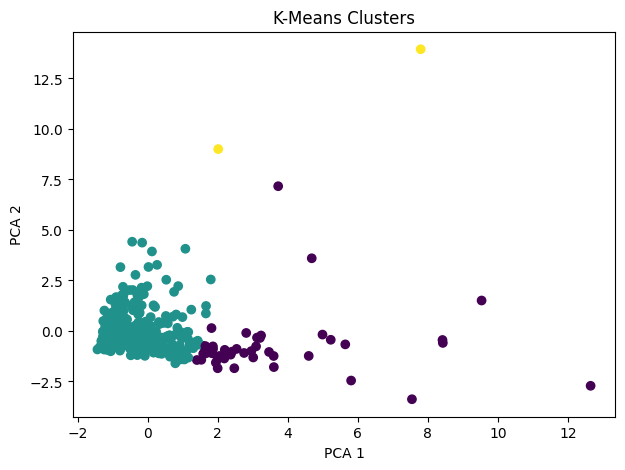

In [15]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters")

plt.show()

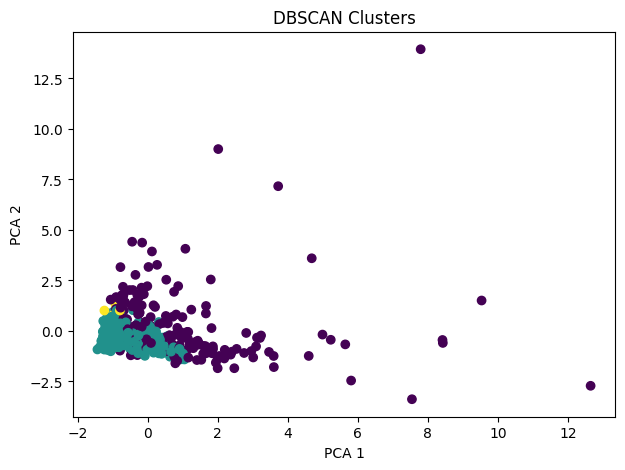

In [16]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DBSCAN Clusters")

plt.show()

In [17]:
cluster_summary = df.groupby(
    "KMeans_Cluster"
)[
    [
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents_Paper",
        "Delicassen"
    ]
].mean()

cluster_summary

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
KMeans_Cluster,,,,,,
0,10440.933333,19386.422222,28656.088889,2190.244444,13327.800000,2374.200000
1,12062.913486,4115.099237,5534.966921,2940.676845,1696.170483,1299.114504
2,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


In [18]:
print("K-Means Clusters:")
print(df["KMeans_Cluster"].value_counts())

print("\nDBSCAN Clusters:")
print(df["DBSCAN_Cluster"].value_counts())

K-Means Clusters:
KMeans_Cluster
1    393
0     45
2      2
Name: count, dtype: int64

DBSCAN Clusters:
DBSCAN_Cluster
 0    261
-1    174
 1      5
Name: count, dtype: int64


K-Means created three groups based on customer spending patterns. One large cluster contains customers with relatively low or moderate spending, while another contains customers spending more on Milk, Grocery and Detergents/Paper. A smaller cluster represents customers with unusually high spending in categories such as Fresh and Delicassen. DBSCAN identifies dense groups of similar customers and marks unusual customers as -1, meaning noise or possible outliers.